In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations
import statsmodels.formula.api as smf
import statsmodels.stats.anova as anova
from statsmodels.stats.outliers_influence import summary_table
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
print("="*78)
print("CODING QUESTION 1: Kelley Blue Book Data Dataset Analysis")
print("="*78)

CODING QUESTION 1: Kelley Blue Book Data Dataset Analysis


In [3]:
# Load the data
data_kbb = pd.read_csv('/Users/lokeshmuvva/Documents/F25_1/regression_f25/data/KelleyBlueBookData.csv')
print("First few rows:")
print(data_kbb.head())

First few rows:
         Price  Mileage   Make    Model      Trim   Type  Cylinder  Liter  \
0  17314.10313     8221  Buick  Century  Sedan 4D  Sedan         6    3.1   
1  17542.03608     9135  Buick  Century  Sedan 4D  Sedan         6    3.1   
2  16218.84786    13196  Buick  Century  Sedan 4D  Sedan         6    3.1   
3  16336.91314    16342  Buick  Century  Sedan 4D  Sedan         6    3.1   
4  16339.17032    19832  Buick  Century  Sedan 4D  Sedan         6    3.1   

   Doors  Cruise  Sound  Leather  
0      4       1      1        1  
1      4       1      1        0  
2      4       1      1        0  
3      4       1      0        0  
4      4       1      0        1  


In [4]:
print("="*78)
print("PART (a): Estimated Coefficient of Leather and t-test Interpretation")
print("="*78)

model_q1 = smf.ols('Price ~ Mileage + C(Type) + C(Cylinder) + Liter + Cruise + Sound + C(Leather)', 
                    data=data_kbb).fit()

print("\nModel Summary:")
print(model_q1.summary())

PART (a): Estimated Coefficient of Leather and t-test Interpretation

Model Summary:
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     202.6
Date:                Sun, 05 Oct 2025   Prob (F-statistic):          1.51e-221
Time:                        17:50:51   Log-Likelihood:                -7998.0
No. Observations:                 804   AIC:                         1.602e+04
Df Residuals:                     792   BIC:                         1.608e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [5]:
# Extract the leather coefficient and t-test results
leather_coef = model_q1.params['C(Leather)[T.1]']
leather_se = model_q1.bse['C(Leather)[T.1]']
leather_t = model_q1.tvalues['C(Leather)[T.1]']
leather_p = model_q1.pvalues['C(Leather)[T.1]']

print("="*78)
print("LEATHER EFFECT RESULTS")
print("="*78)
print(f"\nEstimated coefficient for Leather: β_leather = ${leather_coef:.2f}")
print(f"Standard error: SE(β_leather) = ${leather_se:.2f}")
print(f"t-statistic: t = {leather_t:.4f}")
print(f"p-value: p = {leather_p:.6f}")

print("\n" + "-"*78)
print("HYPOTHESIS TEST")
print("-"*78)
print("H₀: β_leather = 0 (Leather has no effect on price)")
print("H₁: β_leather ≠ 0 (Leather has an effect on price)")

alpha = 0.05
print(f"\nSignificance level: α = {alpha}")

if leather_p < alpha:
    print(f"\nResult: p-value ({leather_p:.6f}) < α ({alpha})")
    print("Decision: REJECT H₀")
    print("\nConclusion: There is statistically significant evidence that leather has an effect on price.")
else:
    print(f"\nResult: p-value ({leather_p:.6f}) ≥ α ({alpha})")
    print("Decision: FAIL TO REJECT H₀")
    print("\nConclusion: There is NOT sufficient evidence that leather has a significant effect on price.")

LEATHER EFFECT RESULTS

Estimated coefficient for Leather: β_leather = $1677.94
Standard error: SE(β_leather) = $433.22
t-statistic: t = 3.8732
p-value: p = 0.000116

------------------------------------------------------------------------------
HYPOTHESIS TEST
------------------------------------------------------------------------------
H₀: β_leather = 0 (Leather has no effect on price)
H₁: β_leather ≠ 0 (Leather has an effect on price)

Significance level: α = 0.05

Result: p-value (0.000116) < α (0.05)
Decision: REJECT H₀

Conclusion: There is statistically significant evidence that leather has an effect on price.


In [6]:
print("-"*78)
print("INTERPRETATION IN CONTEXT")
print("-"*78)

print(f"""
The coefficient for leather (C(Leather)[T.1]) represents the difference in price 
between cars WITH leather seats (Leather=1) and cars WITHOUT leather seats (Leather=0),
holding all other variables constant (Mileage, Type, Cylinder, Liter, Cruise, Sound).

Estimated Effect: ${leather_coef:.2f}
""")

if leather_coef > 0:
    print(f"This means that cars with leather seats cost approximately ${abs(leather_coef):.2f} MORE")
    print("than cars without leather seats, on average, after controlling for other factors.")
else:
    print(f"This means that cars with leather seats cost approximately ${abs(leather_coef):.2f} LESS")
    print("than cars without leather seats, on average, after controlling for other factors.")

print(f"\nStatistical Significance:")
if leather_p < 0.001:
    print(f"The effect is highly significant (p < 0.001), providing very strong evidence")
    print("that leather seats have a real impact on car prices.")
elif leather_p < 0.01:
    print(f"The effect is very significant (p < 0.01), providing strong evidence")
    print("that leather seats have a real impact on car prices.")
elif leather_p < 0.05:
    print(f"The effect is statistically significant (p < 0.05), providing evidence")
    print("that leather seats have a real impact on car prices.")
else:
    print(f"The effect is NOT statistically significant (p = {leather_p:.4f} > 0.05).")
    print("We cannot conclude that leather seats have a meaningful impact on car prices")
    print("based on this data, after controlling for other variables.")

------------------------------------------------------------------------------
INTERPRETATION IN CONTEXT
------------------------------------------------------------------------------

The coefficient for leather (C(Leather)[T.1]) represents the difference in price 
between cars WITH leather seats (Leather=1) and cars WITHOUT leather seats (Leather=0),
holding all other variables constant (Mileage, Type, Cylinder, Liter, Cruise, Sound).

Estimated Effect: $1677.94

This means that cars with leather seats cost approximately $1677.94 MORE
than cars without leather seats, on average, after controlling for other factors.

Statistical Significance:
The effect is highly significant (p < 0.001), providing very strong evidence
that leather seats have a real impact on car prices.


In [7]:
print("="*78)
print("PART (b): Type Variable Analysis - Reference Level and Highest Price")
print("="*78)

# Extract all Type coefficients
print("\nType Coefficients from the Model:")
print("-"*78)
type_params = {param: model_q1.params[param] for param in model_q1.params.index if 'Type' in param}
for param, coef in type_params.items():
    print(f"{param:30s}: ${coef:10.2f}")

# Identify reference level
print("\n" + "-"*78)
print("REFERENCE LEVEL IDENTIFICATION")
print("-"*78)
print("\nUnique car types in the dataset:")
unique_types = sorted(data_kbb['Type'].unique())
print(unique_types)

# The reference level is the one NOT appearing in the coefficients
types_in_model = [param.split('[T.')[1].rstrip(']') for param in type_params.keys()]
reference_type = [t for t in unique_types if t not in types_in_model][0]

print(f"\nReference level: {reference_type}")
print(f"(This is the baseline category with coefficient = $0.00)")
print(f"\nOther types in the model and their effects relative to {reference_type}:")
for param, coef in type_params.items():
    type_name = param.split('[T.')[1].rstrip(']')
    if coef > 0:
        print(f"  • {type_name}: ${coef:+.2f} (higher than {reference_type})")
    else:
        print(f"  • {type_name}: ${coef:+.2f} (lower than {reference_type})")

PART (b): Type Variable Analysis - Reference Level and Highest Price

Type Coefficients from the Model:
------------------------------------------------------------------------------
C(Type)[T.Coupe]              : $ -18570.12
C(Type)[T.Hatchback]          : $ -18310.16
C(Type)[T.Sedan]              : $ -15468.43
C(Type)[T.Wagon]              : $  -9452.12

------------------------------------------------------------------------------
REFERENCE LEVEL IDENTIFICATION
------------------------------------------------------------------------------

Unique car types in the dataset:
['Convertible', 'Coupe', 'Hatchback', 'Sedan', 'Wagon']

Reference level: Convertible
(This is the baseline category with coefficient = $0.00)

Other types in the model and their effects relative to Convertible:
  • Coupe: $-18570.12 (lower than Convertible)
  • Hatchback: $-18310.16 (lower than Convertible)
  • Sedan: $-15468.43 (lower than Convertible)
  • Wagon: $-9452.12 (lower than Convertible)


In [8]:
print("-"*78)
print("WHICH TYPE HAS THE HIGHEST AVERAGE PRICE?")
print("-"*78)

# Calculate effective coefficients (reference = 0, others from model)
type_effects = {reference_type: 0.0}
for param, coef in type_params.items():
    type_name = param.split('[T.')[1].rstrip(']')
    type_effects[type_name] = coef

# Sort by coefficient value
sorted_types = sorted(type_effects.items(), key=lambda x: x[1], reverse=True)

print("\nRanking of car types by their effect on price (holding other variables constant):")
print("\nRank  Type              Coefficient     Interpretation")
print("-"*78)
for i, (type_name, coef) in enumerate(sorted_types, 1):
    if type_name == reference_type:
        print(f"{i:2d}.   {type_name:15s}   ${coef:10.2f}      (Reference level)")
    else:
        print(f"{i:2d}.   {type_name:15s}   ${coef:+10.2f}      (vs {reference_type})")

highest_type = sorted_types[0][0]
highest_coef = sorted_types[0][1]

print("\n" + "="*78)
print("CONCLUSION")
print("="*78)
print(f"\nType with HIGHEST average price: {highest_type}")

if highest_type == reference_type:
    print(f"\nThe reference level ({reference_type}) has the highest price because all other")
    print(f"type coefficients are negative, meaning they decrease the price relative to {reference_type}.")
else:
    print(f"\n{highest_type} has the highest average price with a coefficient of ${highest_coef:+.2f}")
    print(f"relative to the reference level ({reference_type}).")
    print(f"\nThis means {highest_type} cars cost approximately ${abs(highest_coef):.2f} MORE than")
    print(f"{reference_type} cars, after controlling for Mileage, Cylinder, Liter, Cruise, Sound, and Leather.")

------------------------------------------------------------------------------
WHICH TYPE HAS THE HIGHEST AVERAGE PRICE?
------------------------------------------------------------------------------

Ranking of car types by their effect on price (holding other variables constant):

Rank  Type              Coefficient     Interpretation
------------------------------------------------------------------------------
 1.   Convertible       $      0.00      (Reference level)
 2.   Wagon             $  -9452.12      (vs Convertible)
 3.   Sedan             $ -15468.43      (vs Convertible)
 4.   Hatchback         $ -18310.16      (vs Convertible)
 5.   Coupe             $ -18570.12      (vs Convertible)

CONCLUSION

Type with HIGHEST average price: Convertible

The reference level (Convertible) has the highest price because all other
type coefficients are negative, meaning they decrease the price relative to Convertible.


In [9]:
print("="*78)
print("PART (c): Cylinder Analysis - Price Comparison for Cylinder=6")
print("="*78)

# Extract all Cylinder coefficients
print("\nCylinder Coefficients from the Model:")
print("-"*78)
cylinder_params = {param: model_q1.params[param] for param in model_q1.params.index if 'Cylinder' in param}
for param, coef in cylinder_params.items():
    print(f"{param:30s}: ${coef:10.2f}")

# Identify reference level for Cylinder
print("\n" + "-"*78)
print("REFERENCE LEVEL IDENTIFICATION")
print("-"*78)
print("\nUnique cylinder levels in the dataset:")
unique_cylinders = sorted(data_kbb['Cylinder'].unique())
print(unique_cylinders)

# The reference level is the one NOT appearing in the coefficients
cylinders_in_model = [int(param.split('[T.')[1].rstrip(']')) for param in cylinder_params.keys()]
reference_cylinder = [c for c in unique_cylinders if c not in cylinders_in_model][0]

print(f"\nReference level: {reference_cylinder} cylinders")
print(f"(This is the baseline category with coefficient = $0.00)")

PART (c): Cylinder Analysis - Price Comparison for Cylinder=6

Cylinder Coefficients from the Model:
------------------------------------------------------------------------------
C(Cylinder)[T.6]              : $   1360.13
C(Cylinder)[T.8]              : $  14164.75

------------------------------------------------------------------------------
REFERENCE LEVEL IDENTIFICATION
------------------------------------------------------------------------------

Unique cylinder levels in the dataset:
[np.int64(4), np.int64(6), np.int64(8)]

Reference level: 4 cylinders
(This is the baseline category with coefficient = $0.00)


In [10]:
print("-"*78)
print("PRICE COMPARISON: CYLINDER = 6 vs OTHER LEVELS")
print("-"*78)

# Create effective coefficients for all cylinder levels
cylinder_effects = {reference_cylinder: 0.0}
for param, coef in cylinder_params.items():
    cyl_level = int(param.split('[T.')[1].rstrip(']'))
    cylinder_effects[cyl_level] = coef

# Sort by cylinder count
sorted_cylinders = sorted(cylinder_effects.items(), key=lambda x: x[0])

print("All Cylinder Levels and Their Effects on Price:")
print("\nCylinders   Coefficient     Effect Relative to Reference")
print("-"*78)
for cyl, coef in sorted_cylinders:
    if cyl == reference_cylinder:
        print(f"   {cyl:2d}       ${coef:10.2f}     (Reference level)")
    else:
        if coef > 0:
            print(f"   {cyl:2d}       ${coef:+10.2f}     ${abs(coef):.2f} HIGHER than {reference_cylinder}-cylinder")
        else:
            print(f"   {cyl:2d}       ${coef:+10.2f}     ${abs(coef):.2f} LOWER than {reference_cylinder}-cylinder")

# Focus on Cylinder = 6
print("\n" + "="*78)
print("SPECIFIC ANALYSIS: CYLINDER = 6")
print("="*78)

if 6 in cylinder_effects:
    cyl6_coef = cylinder_effects[6]
    
    if 6 == reference_cylinder:
        print(f"\n6-cylinder is the REFERENCE level (coefficient = $0.00)")
        print(f"\nComparison with other cylinder levels:")
        for cyl, coef in sorted_cylinders:
            if cyl != 6:
                if coef > 0:
                    print(f"  • {cyl}-cylinder cars cost ${abs(coef):.2f} MORE than 6-cylinder cars")
                else:
                    print(f"  • {cyl}-cylinder cars cost ${abs(coef):.2f} LESS than 6-cylinder cars")
    else:
        print(f"\n6-cylinder coefficient: ${cyl6_coef:+.2f} (relative to {reference_cylinder}-cylinder)")
        
        if cyl6_coef > 0:
            print(f"\n6-cylinder cars cost ${abs(cyl6_coef):.2f} MORE than {reference_cylinder}-cylinder cars")
        else:
            print(f"\n6-cylinder cars cost ${abs(cyl6_coef):.2f} LESS than {reference_cylinder}-cylinder cars")
        
        print(f"\nComparison with ALL other cylinder levels:")
        for cyl, coef in sorted_cylinders:
            if cyl != 6:
                diff = cyl6_coef - coef
                if diff > 0:
                    print(f"  • 6-cylinder costs ${abs(diff):.2f} MORE than {cyl}-cylinder")
                elif diff < 0:
                    print(f"  • 6-cylinder costs ${abs(diff):.2f} LESS than {cyl}-cylinder")
                else:
                    print(f"  • 6-cylinder has the SAME price effect as {cyl}-cylinder")
else:
    print("\n6-cylinder cars are not present in the dataset.")

------------------------------------------------------------------------------
PRICE COMPARISON: CYLINDER = 6 vs OTHER LEVELS
------------------------------------------------------------------------------
All Cylinder Levels and Their Effects on Price:

Cylinders   Coefficient     Effect Relative to Reference
------------------------------------------------------------------------------
    4       $      0.00     (Reference level)
    6       $  +1360.13     $1360.13 HIGHER than 4-cylinder
    8       $ +14164.75     $14164.75 HIGHER than 4-cylinder

SPECIFIC ANALYSIS: CYLINDER = 6

6-cylinder coefficient: $+1360.13 (relative to 4-cylinder)

6-cylinder cars cost $1360.13 MORE than 4-cylinder cars

Comparison with ALL other cylinder levels:
  • 6-cylinder costs $1360.13 MORE than 4-cylinder
  • 6-cylinder costs $12804.62 LESS than 8-cylinder


In [11]:
# Statistical significance of cylinder effects
print("-"*78)
print("STATISTICAL SIGNIFICANCE OF CYLINDER EFFECTS")
print("-"*78)

print("\nT-tests and p-values for Cylinder coefficients:")
print("\nCylinders   Coefficient    t-statistic    p-value      Significant?")
print("-"*78)

# Reference level
print(f"   {reference_cylinder:2d}       ${0.0:10.2f}       ---           ---          (Reference)")

# Other levels
for param in cylinder_params.keys():
    cyl_level = int(param.split('[T.')[1].rstrip(']'))
    coef = model_q1.params[param]
    t_stat = model_q1.tvalues[param]
    p_val = model_q1.pvalues[param]
    sig = "YES ***" if p_val < 0.001 else "YES **" if p_val < 0.01 else "YES *" if p_val < 0.05 else "NO"
    print(f"   {cyl_level:2d}       ${coef:+10.2f}     {t_stat:8.4f}     {p_val:8.6f}     {sig}")

print("\n* p < 0.05,  ** p < 0.01,  *** p < 0.001")

------------------------------------------------------------------------------
STATISTICAL SIGNIFICANCE OF CYLINDER EFFECTS
------------------------------------------------------------------------------

T-tests and p-values for Cylinder coefficients:

Cylinders   Coefficient    t-statistic    p-value      Significant?
------------------------------------------------------------------------------
    4       $      0.00       ---           ---          (Reference)
    6       $  +1360.13       1.2647     0.206349     NO
    8       $ +14164.75       7.2306     0.000000     YES ***

* p < 0.05,  ** p < 0.01,  *** p < 0.001


In [12]:
print("="*78)
print("PART (d): Partial (Type II) ANOVA - F-test for Cylinder")
print("="*78)

# Run Type II (Partial) ANOVA
anova_type2_q1 = anova.anova_lm(model_q1, typ=2)
print("\nType II (Partial) ANOVA Table:")
print("="*78)
print(anova_type2_q1)
print("\n" + "="*78)

PART (d): Partial (Type II) ANOVA - F-test for Cylinder

Type II (Partial) ANOVA Table:
                   sum_sq     df           F        PR(>F)
C(Type)      1.381333e+10    4.0  132.939757  7.297205e-87
C(Cylinder)  5.348559e+09    2.0  102.949252  1.807044e-40
C(Leather)   3.896844e+08    1.0   15.001317  1.163062e-04
Mileage      1.879060e+09    1.0   72.336414  8.996777e-17
Liter        8.380606e+07    1.0    3.226204  7.284949e-02
Cruise       2.504757e+09    1.0   96.423312  1.485766e-21
Sound        3.476617e+04    1.0    0.001338  9.708262e-01
Residual     2.057353e+10  792.0         NaN           NaN



In [13]:
print("-"*78)
print("INTERPRETATION OF PARTIAL F-TEST FOR CYLINDER")
print("-"*78)

# Extract F-test results for Cylinder
cylinder_f = anova_type2_q1.loc['C(Cylinder)', 'F']
cylinder_p = anova_type2_q1.loc['C(Cylinder)', 'PR(>F)']
cylinder_df = anova_type2_q1.loc['C(Cylinder)', 'df']
cylinder_ss = anova_type2_q1.loc['C(Cylinder)', 'sum_sq']

print("\nThe Type II (Partial) F-test for Cylinder tests:")
print("  H₀: All Cylinder coefficients = 0 (Cylinder has NO effect on Price)")
print("      given that ALL other predictors are in the model")
print("  H₁: At least one Cylinder coefficient ≠ 0 (Cylinder DOES affect Price)")
print("      given that ALL other predictors are in the model")

print("\nIn other words:")
print("  • Reduced model: Price ~ Mileage + Type + Liter + Cruise + Sound + Leather")
print("  • Full model:    Price ~ Mileage + Type + Cylinder + Liter + Cruise + Sound + Leather")
print("\nThe F-test asks: Does adding Cylinder significantly improve the model,")
print("given that all other variables are already included?")

alpha = 0.05
print(f"\n\nSignificance level: α = {alpha}")

if cylinder_p < alpha:
    print(f"\nResult: p-value ({cylinder_p:.6f}) < α ({alpha})")
    print("Decision: REJECT H₀")
    print("\nConclusion: Cylinder is a statistically significant predictor of Price.")
    print("At least one cylinder level has a significantly different effect on price")
    print("compared to the reference level, after controlling for all other variables.")
else:
    print(f"\nResult: p-value ({cylinder_p:.6f}) ≥ α ({alpha})")
    print("Decision: FAIL TO REJECT H₀")
    print("\nConclusion: Cylinder is NOT a statistically significant predictor of Price.")
    print("We cannot conclude that cylinder levels have different effects on price")
    print("after controlling for all other variables.")

------------------------------------------------------------------------------
INTERPRETATION OF PARTIAL F-TEST FOR CYLINDER
------------------------------------------------------------------------------

The Type II (Partial) F-test for Cylinder tests:
  H₀: All Cylinder coefficients = 0 (Cylinder has NO effect on Price)
      given that ALL other predictors are in the model
  H₁: At least one Cylinder coefficient ≠ 0 (Cylinder DOES affect Price)
      given that ALL other predictors are in the model

In other words:
  • Reduced model: Price ~ Mileage + Type + Liter + Cruise + Sound + Leather
  • Full model:    Price ~ Mileage + Type + Cylinder + Liter + Cruise + Sound + Leather

The F-test asks: Does adding Cylinder significantly improve the model,
given that all other variables are already included?


Significance level: α = 0.05

Result: p-value (0.000000) < α (0.05)
Decision: REJECT H₀

Conclusion: Cylinder is a statistically significant predictor of Price.
At least one cylinder l

In [14]:
print("="*78)
print("FINAL CONCLUSION: IS CYLINDER A SIGNIFICANT PREDICTOR?")
print("="*78)

# Determine overall conclusion
f_significant = cylinder_p < 0.05

print(f"\nF-test result: {'SIGNIFICANT' if f_significant else 'NOT SIGNIFICANT'} (p = {cylinder_p:.6f})")


if f_significant:
    print(f"\n✓ YES, Cylinder IS a significant predictor of Price.")
    print(f"\nReasoning:")
    print(f"  • The F-test (p = {cylinder_p:.6f}) shows that Cylinder as a whole")
    print(f"    significantly improves the model's ability to predict Price.")
    print(f"  • This means that including Cylinder information provides valuable")
    print(f"    predictive power beyond what the other variables already provide.")
    print(f"\n  • Recommendation: KEEP Cylinder in the model.")
    
else:
    print(f"\n✗ NO, Cylinder is NOT a significant predictor of Price.")
    print(f"\nReasoning:")
    print(f"  • The F-test (p = {cylinder_p:.6f}) indicates that Cylinder as a whole")
    print(f"    does NOT significantly improve the model's predictive ability.")
    print(f"  • Even though individual t-tests may show some differences,")
    print(f"    the overall F-test is the definitive test for including a")
    print(f"    categorical variable with multiple levels.")
    print(f"\n  • Recommendation: Consider REMOVING Cylinder from the model")
    print(f"    (or at least question its practical importance).")

FINAL CONCLUSION: IS CYLINDER A SIGNIFICANT PREDICTOR?

F-test result: SIGNIFICANT (p = 0.000000)

✓ YES, Cylinder IS a significant predictor of Price.

Reasoning:
  • The F-test (p = 0.000000) shows that Cylinder as a whole
    significantly improves the model's ability to predict Price.
  • This means that including Cylinder information provides valuable
    predictive power beyond what the other variables already provide.

  • Recommendation: KEEP Cylinder in the model.


In [15]:
print("="*78)
print("QUESTION 2: Ice Cream Consumption - Multicollinearity Analysis")
print("="*78)

QUESTION 2: Ice Cream Consumption - Multicollinearity Analysis


In [16]:
# Load the Ice Cream Consumption data
data_ice = pd.read_csv('/Users/lokeshmuvva/Documents/F25_1/regression_f25/data/IceCreamConsumption.csv')
print("First few rows:")
print(data_ice.head())

First few rows:
    cons  income  price  temp  time
0  0.386      78  0.270    41     1
1  0.374      79  0.282    56     2
2  0.393      81  0.277    63     3
3  0.425      80  0.280    68     4
4  0.406      76  0.272    69     5


In [17]:
print("="*78)
print("PART (a): Variance Inflation Factors (VIF)")
print("="*78)

# Fit the regression model: cons ~ income + price + temp
model_ice = smf.ols('cons ~ income + price + temp', data=data_ice).fit()
print("\nModel Summary:")
print(model_ice.summary())

PART (a): Variance Inflation Factors (VIF)

Model Summary:
                            OLS Regression Results                            
Dep. Variable:                   cons   R-squared:                       0.719
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     22.17
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           2.45e-07
Time:                        17:50:51   Log-Likelihood:                 58.619
No. Observations:                  30   AIC:                            -109.2
Df Residuals:                      26   BIC:                            -103.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [18]:
# Calculate Variance Inflation Factors (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create the design matrix (X) with predictors only (exclude intercept for VIF calculation)
X = data_ice[['income', 'price', 'temp']]

# Calculate VIF for each predictor
print("-"*78)
print("VARIANCE INFLATION FACTORS (VIF)")
print("-"*78)

from statsmodels.tools.tools import add_constant

# Add constant column
X_with_const = add_constant(data_ice[['income', 'price', 'temp']])

# Calculate VIF (skip index 0, which is the constant)
vif_data = pd.DataFrame()
vif_data['Predictor'] = ['income', 'price', 'temp']
vif_data['VIF'] = [variance_inflation_factor(X_with_const.values, i+1) for i in range(3)]

print(vif_data.to_string(index=False))

------------------------------------------------------------------------------
VARIANCE INFLATION FACTORS (VIF)
------------------------------------------------------------------------------
Predictor      VIF
   income 1.144186
    price 1.035673
     temp 1.144367


In [19]:
print("="*78)
print("DETAILED INTERPRETATION OF VIF RESULTS")
print("="*78)

# Analyze each VIF value
for idx, row in vif_data.iterrows():
    predictor = row['Predictor']
    vif = row['VIF']
    
    print(f"\n{predictor.upper()}:")
    print(f"  VIF = {vif:.4f}")
    
    if vif < 1.5:
        interpretation = "negligible multicollinearity"
    elif vif < 5:
        interpretation = "low to moderate multicollinearity"
    elif vif < 10:
        interpretation = "moderate to high multicollinearity"
    elif vif < 100:
        interpretation = "severe multicollinearity"
    else:
        interpretation = "extreme multicollinearity"
    
    print(f"  Interpretation: {interpretation}")
    
    # Calculate R-squared from VIF: VIF = 1/(1-R²) => R² = 1 - 1/VIF
    r_squared = 1 - 1/vif if vif > 1 else 0
    print(f"  R² from other predictors: {r_squared:.4f}")
    print(f"    (This means {r_squared*100:.2f}% of {predictor}'s variance is explained by other predictors)")
    
    # Variance inflation
    inflation_pct = (vif - 1) * 100
    print(f"  Variance inflation: {inflation_pct:.2f}%")
    print(f"    (Standard errors are inflated by a factor of {np.sqrt(vif):.2f})")

DETAILED INTERPRETATION OF VIF RESULTS

INCOME:
  VIF = 1.1442
  Interpretation: negligible multicollinearity
  R² from other predictors: 0.1260
    (This means 12.60% of income's variance is explained by other predictors)
  Variance inflation: 14.42%
    (Standard errors are inflated by a factor of 1.07)

PRICE:
  VIF = 1.0357
  Interpretation: negligible multicollinearity
  R² from other predictors: 0.0344
    (This means 3.44% of price's variance is explained by other predictors)
  Variance inflation: 3.57%
    (Standard errors are inflated by a factor of 1.02)

TEMP:
  VIF = 1.1444
  Interpretation: negligible multicollinearity
  R² from other predictors: 0.1262
    (This means 12.62% of temp's variance is explained by other predictors)
  Variance inflation: 14.44%
    (Standard errors are inflated by a factor of 1.07)


In [20]:
print("="*78)
print("FINAL CONCLUSION")
print("="*78)

# Identify problematic predictors
high_vif_vars = vif_data[vif_data['VIF'] > 10]['Predictor'].tolist()
moderate_vif_vars = vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)]['Predictor'].tolist()

if high_vif_vars:
    print(f"\nPredictors with SEVERE multicollinearity (VIF > 10): {high_vif_vars}")
elif moderate_vif_vars:
    print(f"\nPredictors with MODERATE multicollinearity (VIF > 5): {moderate_vif_vars}")
else:
    print(f"\nNo predictors have severe multicollinearity (all VIF < 5)")


FINAL CONCLUSION

No predictors have severe multicollinearity (all VIF < 5)


In [21]:
print("="*78)
print("PART (b): Step-by-Step Calculation of VIF for 'income'")
print("="*78)

print("""
VIF (Variance Inflation Factor) measures how much the variance of a regression
coefficient is inflated due to multicollinearity with other predictors.

FORMULA:
    VIF_j = 1 / (1 - R²_j)

where R²_j is the R-squared from regressing predictor j on all other predictors.

For 'income', we need to:
    1. Regress 'income' on the OTHER predictors (price and temp)
    2. Get the R² from this auxiliary regression
    3. Calculate VIF = 1 / (1 - R²)
""")

PART (b): Step-by-Step Calculation of VIF for 'income'

VIF (Variance Inflation Factor) measures how much the variance of a regression
coefficient is inflated due to multicollinearity with other predictors.

FORMULA:
    VIF_j = 1 / (1 - R²_j)

where R²_j is the R-squared from regressing predictor j on all other predictors.

For 'income', we need to:
    1. Regress 'income' on the OTHER predictors (price and temp)
    2. Get the R² from this auxiliary regression
    3. Calculate VIF = 1 / (1 - R²)



In [22]:
print("="*78)
print("STEP 1: Regress 'income' on the OTHER predictors (price and temp)")
print("="*78)

# Auxiliary regression: income ~ price + temp
auxiliary_model = smf.ols('income ~ price + temp', data=data_ice).fit()

print("\n" + "-"*78)
print("KEY INFORMATION FROM AUXILIARY REGRESSION:")
print("-"*78)
print(f"\nR-squared (R²): {auxiliary_model.rsquared:.6f}")
print(f"Adjusted R²:     {auxiliary_model.rsquared_adj:.6f}")
print(f"F-statistic:     {auxiliary_model.fvalue:.4f}")
print(f"Prob(F):         {auxiliary_model.f_pvalue:.6f}")

print("\n" + "-"*78)
print("INTERPRETATION OF R²:")
print("-"*78)
print(f"""
R² = {auxiliary_model.rsquared:.6f} means that {auxiliary_model.rsquared*100:.2f}% of the variance in 'income'
is explained by 'price' and 'temp' together.

In other words, {auxiliary_model.rsquared*100:.2f}% of the information in 'income' is redundant
because it can be predicted from the other predictors.
""")

STEP 1: Regress 'income' on the OTHER predictors (price and temp)

------------------------------------------------------------------------------
KEY INFORMATION FROM AUXILIARY REGRESSION:
------------------------------------------------------------------------------

R-squared (R²): 0.126016
Adjusted R²:     0.061276
F-statistic:     1.9465
Prob(F):         0.162292

------------------------------------------------------------------------------
INTERPRETATION OF R²:
------------------------------------------------------------------------------

R² = 0.126016 means that 12.60% of the variance in 'income'
is explained by 'price' and 'temp' together.

In other words, 12.60% of the information in 'income' is redundant
because it can be predicted from the other predictors.



In [23]:
print("="*78)
print("STEP 2: Calculate VIF using the formula VIF = 1 / (1 - R²)")
print("="*78)

r_squared = auxiliary_model.rsquared

print(f"\nGiven:")
print(f"  R² = {r_squared:.6f}")

print(f"\nCalculation:")
print(f"  1 - R² = 1 - {r_squared:.6f} = {1 - r_squared:.6f}")
print(f"  VIF = 1 / (1 - R²)")
print(f"      = 1 / {1 - r_squared:.6f}")

vif_income_manual = 1 / (1 - r_squared)
print(f"      = {vif_income_manual:.6f}")

print("\n" + "-"*78)
print("VERIFICATION:")
print("-"*78)

# Get the VIF from our earlier calculation
vif_income_from_table = vif_data[vif_data['Predictor'] == 'income']['VIF'].values[0]

print(f"\nManually calculated VIF for income: {vif_income_manual:.6f}")
print(f"VIF from statsmodels function:      {vif_income_from_table:.6f}")
print(f"Difference:                          {abs(vif_income_manual - vif_income_from_table):.10f}")

STEP 2: Calculate VIF using the formula VIF = 1 / (1 - R²)

Given:
  R² = 0.126016

Calculation:
  1 - R² = 1 - 0.126016 = 0.873984
  VIF = 1 / (1 - R²)
      = 1 / 0.873984
      = 1.144186

------------------------------------------------------------------------------
VERIFICATION:
------------------------------------------------------------------------------

Manually calculated VIF for income: 1.144186
VIF from statsmodels function:      1.144186
Difference:                          0.0000000000


In [24]:
print("="*78)
print("STEP 3: Interpret the VIF for 'income'")
print("="*78)

print(f"""
VIF for 'income' = {vif_income_manual:.6f}

WHAT THIS MEANS:

1. VARIANCE INFLATION:
   The variance of the coefficient for 'income' in the original regression
   (cons ~ income + price + temp) is inflated by a factor of {vif_income_manual:.4f}
   due to its correlation with 'price' and 'temp'.
   
2. STANDARD ERROR INFLATION:
   Standard errors are inflated by a factor of √VIF = √{vif_income_manual:.4f} = {np.sqrt(vif_income_manual):.4f}
   
   This means the standard error is {(np.sqrt(vif_income_manual) - 1)*100:.2f}% larger than it would be
   if 'income' were uncorrelated with the other predictors.

3. REDUNDANT INFORMATION:
   R² = {r_squared:.6f} means that {r_squared*100:.2f}% of 'income' can be predicted
   from 'price' and 'temp'.
   
   Only {(1-r_squared)*100:.2f}% of 'income' contains unique information not already
   captured by the other predictors.
""")

if vif_income_manual < 5:
    print(f"   Since VIF = {vif_income_manual:.4f} < 5, multicollinearity is LOW to MODERATE.")
    print("   The coefficient for 'income' should be reasonably stable and reliable.")
elif vif_income_manual < 10:
    print(f"   Since VIF = {vif_income_manual:.4f} is between 5 and 10, multicollinearity is MODERATE.")
    print("   The coefficient for 'income' may be somewhat unstable.")
    print("   Interpret with caution.")
else:
    print(f"   Since VIF = {vif_income_manual:.4f} > 10, multicollinearity is SEVERE.")
    print("   The coefficient for 'income' is likely very unstable.")
    print("   Statistical inference about 'income' may be unreliable.")

STEP 3: Interpret the VIF for 'income'

VIF for 'income' = 1.144186

WHAT THIS MEANS:

1. VARIANCE INFLATION:
   The variance of the coefficient for 'income' in the original regression
   (cons ~ income + price + temp) is inflated by a factor of 1.1442
   due to its correlation with 'price' and 'temp'.
   
2. STANDARD ERROR INFLATION:
   Standard errors are inflated by a factor of √VIF = √1.1442 = 1.0697
   
   This means the standard error is 6.97% larger than it would be
   if 'income' were uncorrelated with the other predictors.

3. REDUNDANT INFORMATION:
   R² = 0.126016 means that 12.60% of 'income' can be predicted
   from 'price' and 'temp'.
   
   Only 87.40% of 'income' contains unique information not already
   captured by the other predictors.

   Since VIF = 1.1442 < 5, multicollinearity is LOW to MODERATE.
   The coefficient for 'income' should be reasonably stable and reliable.


In [25]:
print("="*78)
print("PART (c): Influence Plot - Leverage, Studentized Residuals, Cook's Distance")
print("="*78)

PART (c): Influence Plot - Leverage, Studentized Residuals, Cook's Distance


In [26]:
# Calculate influence measures
from statsmodels.stats.outliers_influence import OLSInfluence

# Get influence measures
influence = OLSInfluence(model_ice)

# Extract key measures
leverage = influence.hat_matrix_diag  # Leverage values (h_ii)
studentized_resid = influence.resid_studentized_external  # Externally studentized residuals
cooks_d = influence.cooks_distance[0]  # Cook's distance (returns tuple, take first element)

print("Influence Measures Summary:")
print("-"*78)
print(f"Number of observations: {len(leverage)}")
print(f"\nLeverage (hat values):")
print(f"  Range: [{leverage.min():.6f}, {leverage.max():.6f}]")
print(f"  Mean:  {leverage.mean():.6f}")
print(f"  Average leverage (p/n): {model_ice.df_model + 1}/{len(leverage)} = {(model_ice.df_model + 1)/len(leverage):.6f}")

print(f"\nExternally Studentized Residuals:")
print(f"  Range: [{studentized_resid.min():.6f}, {studentized_resid.max():.6f}]")
print(f"  Mean:  {studentized_resid.mean():.6f}")

print(f"\nCook's Distance:")
print(f"  Range: [{cooks_d.min():.6f}, {cooks_d.max():.6f}]")
print(f"  Mean:  {cooks_d.mean():.6f}")

Influence Measures Summary:
------------------------------------------------------------------------------
Number of observations: 30

Leverage (hat values):
  Range: [0.039961, 0.277922]
  Mean:  0.133333
  Average leverage (p/n): 4.0/30 = 0.133333

Externally Studentized Residuals:
  Range: [-1.973992, 2.749195]
  Mean:  0.011133

Cook's Distance:
  Range: [0.000009, 0.471526]
  Mean:  0.042245


In [27]:
print("="*78)
print("IDENTIFYING INFLUENTIAL OBSERVATIONS")
print("="*78)

# Find observations with highest values
idx_max_leverage = leverage.argmax()
idx_max_studres = np.abs(studentized_resid).argmax()  # Highest absolute value
idx_max_cooks = cooks_d.argmax()

print(f"\nObservation with HIGHEST LEVERAGE:")
print(f"  Index: {idx_max_leverage}")
print(f"  Leverage (h_ii): {leverage[idx_max_leverage]:.6f}")

print(f"\nObservation with HIGHEST STUDENTIZED RESIDUAL (absolute value):")
print(f"  Index: {idx_max_studres}")
print(f"  Studentized Residual: {studentized_resid[idx_max_studres]:.6f}")

print(f"\nObservation with HIGHEST COOK'S DISTANCE:")
print(f"  Index: {idx_max_cooks}")
print(f"  Cook's Distance: {cooks_d[idx_max_cooks]:.6f}")

IDENTIFYING INFLUENTIAL OBSERVATIONS

Observation with HIGHEST LEVERAGE:
  Index: 8
  Leverage (h_ii): 0.277922

Observation with HIGHEST STUDENTIZED RESIDUAL (absolute value):
  Index: 29
  Studentized Residual: 2.749195

Observation with HIGHEST COOK'S DISTANCE:
  Index: 29
  Cook's Distance: 0.471526


CREATING INFLUENCE PLOT


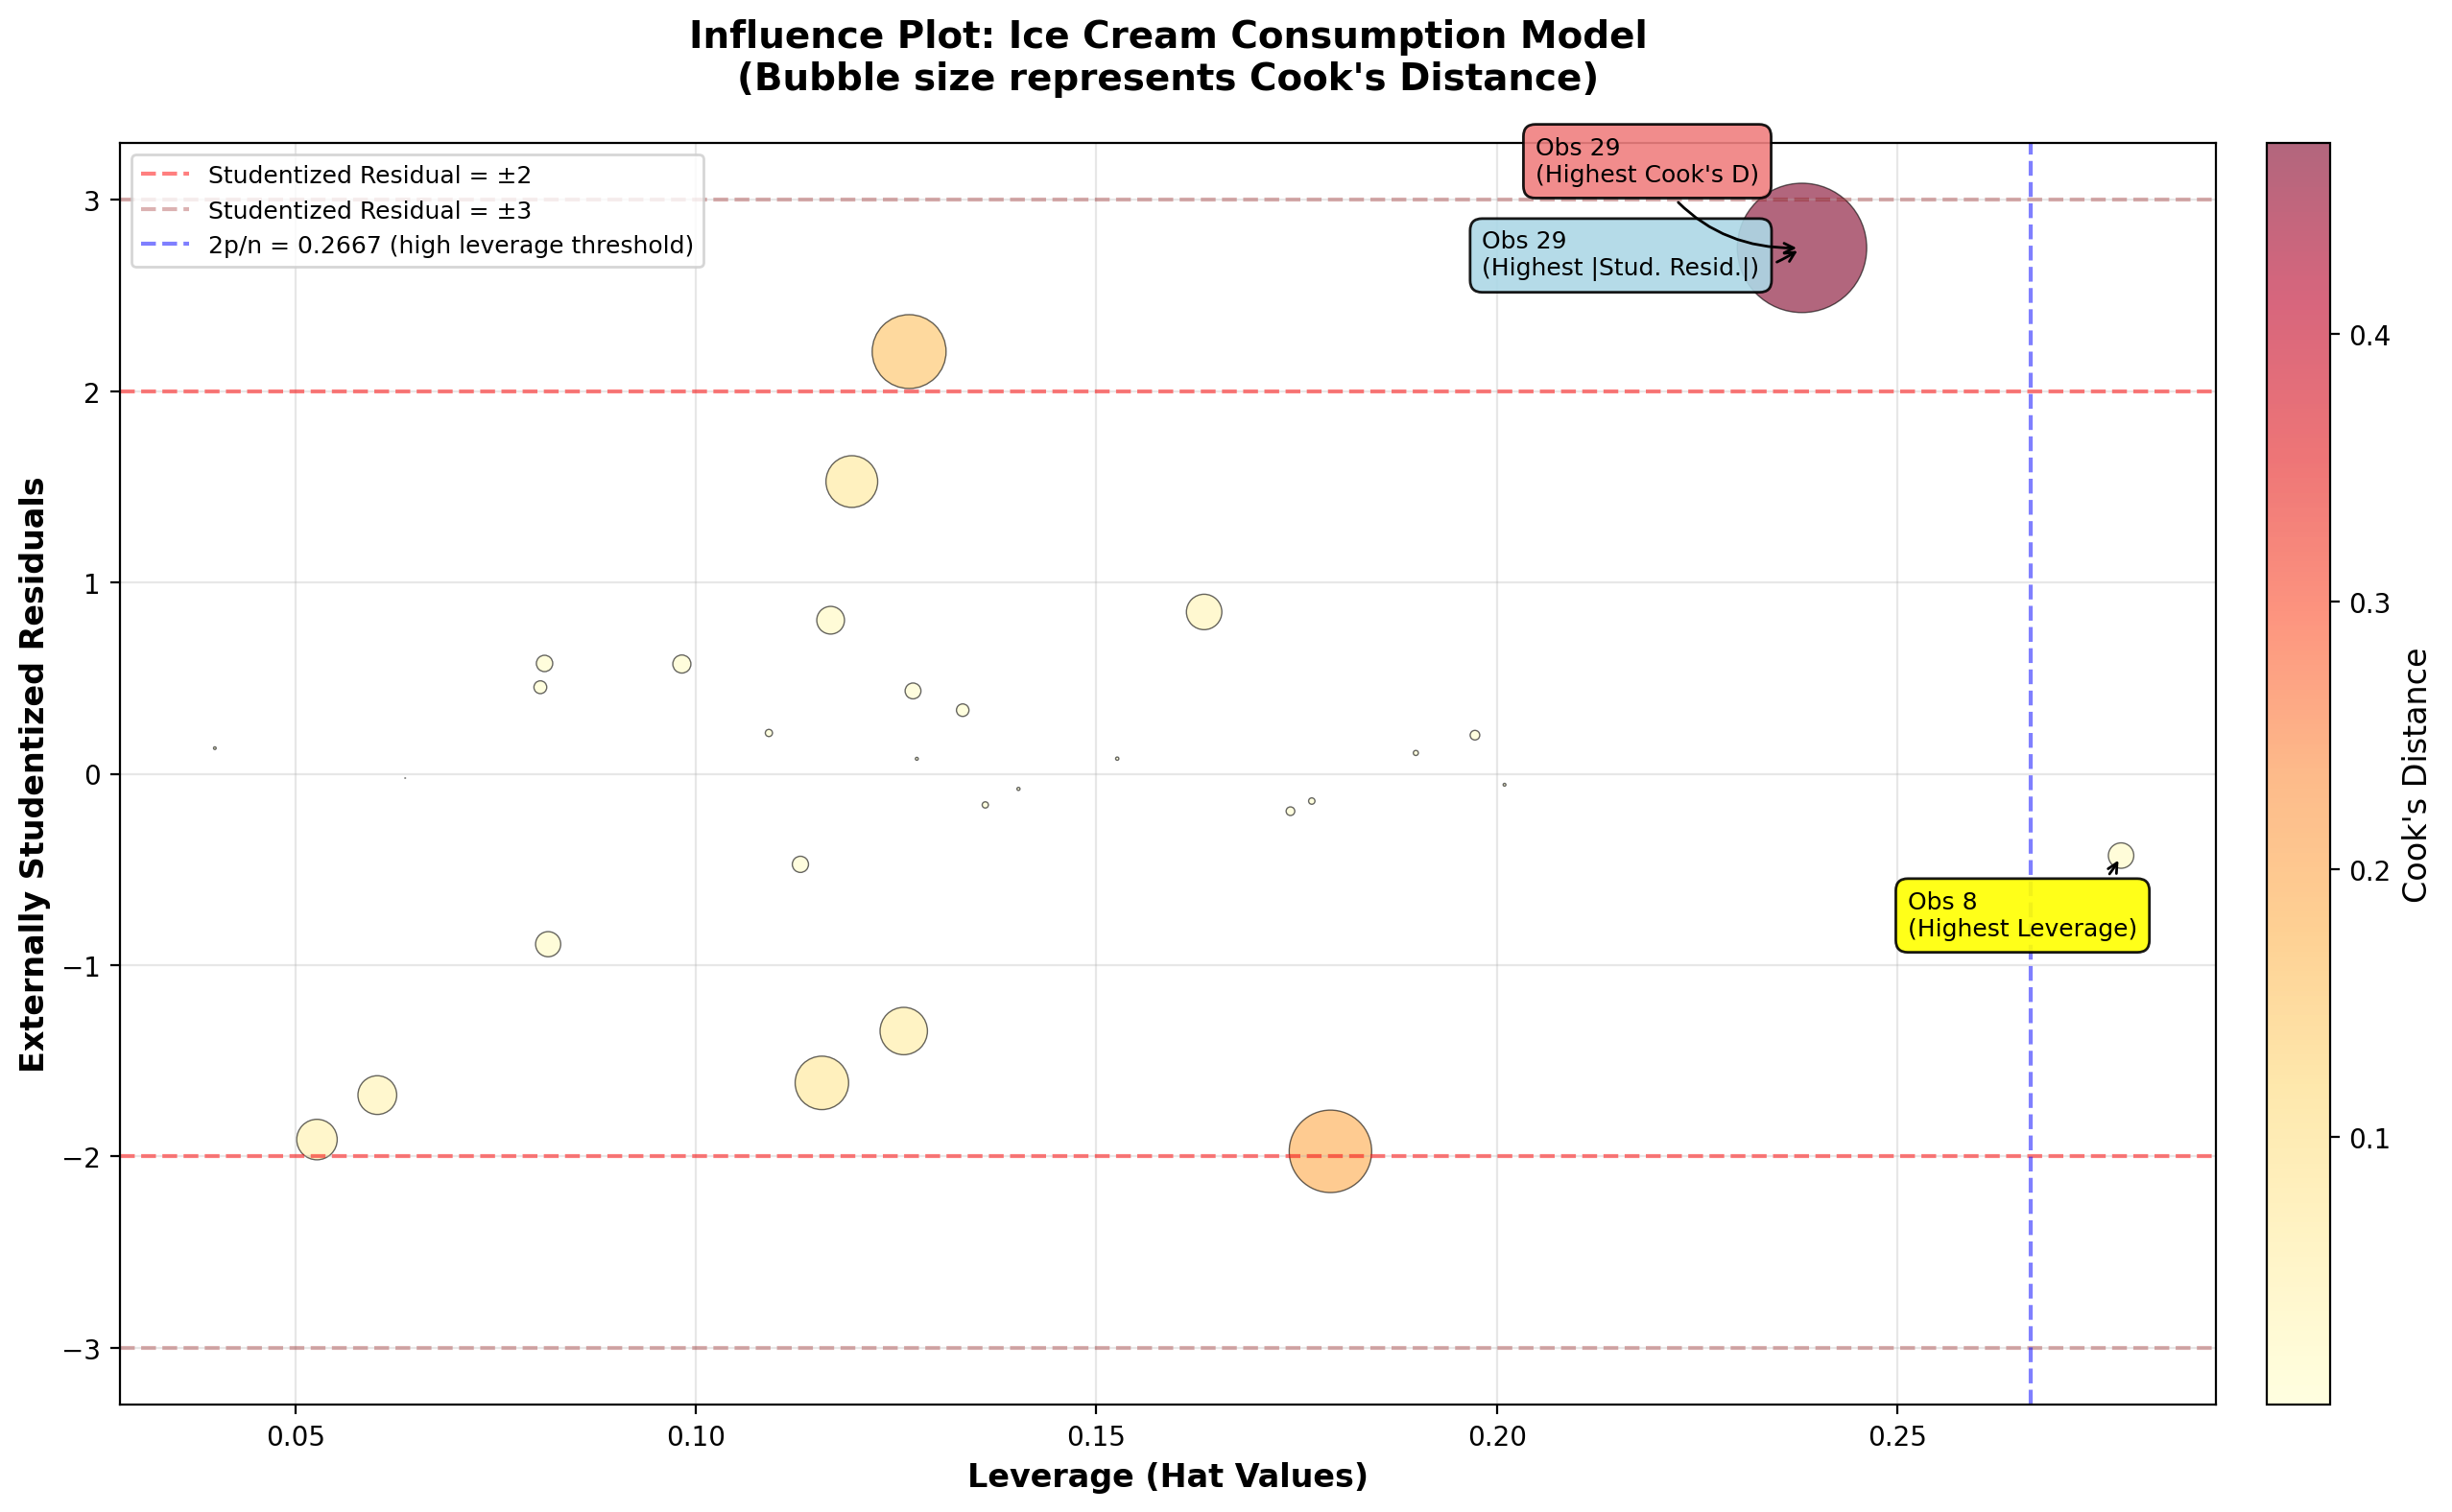

In [28]:
print("="*78)
print("CREATING INFLUENCE PLOT")
print("="*78)

%config InlineBackend.figure_format = 'retina' 

# Create the influence plot with extra space for colorbar
fig, ax = plt.subplots(figsize=(14, 8))

# Scale Cook's distance for bubble sizes (multiply by a constant for visibility)
# Use size proportional to Cook's distance
bubble_sizes = cooks_d * 5000  # Scale factor for visibility

# Create scatter plot
scatter = ax.scatter(leverage, studentized_resid, s=bubble_sizes, 
                     alpha=0.6, c=cooks_d, cmap='YlOrRd', edgecolors='black', linewidth=0.5)

# Add reference lines
# Horizontal lines at ±2 for studentized residuals (outlier threshold)
ax.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='Studentized Residual = ±2')
ax.axhline(y=-2, color='red', linestyle='--', alpha=0.5)
ax.axhline(y=3, color='darkred', linestyle='--', alpha=0.3, label='Studentized Residual = ±3')
ax.axhline(y=-3, color='darkred', linestyle='--', alpha=0.3)

# Vertical line at average leverage: 2*p/n (rule of thumb for high leverage)
avg_leverage = 2 * (model_ice.df_model + 1) / len(leverage)
ax.axvline(x=avg_leverage, color='blue', linestyle='--', alpha=0.5, 
           label=f'2p/n = {avg_leverage:.4f} (high leverage threshold)')

# Add colorbar FIRST, positioned to the right
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Cook's Distance", fontsize=12)

# Now add labels - position them away from the colorbar (on the left side)
# Label point with highest leverage
ax.annotate(f'Obs {idx_max_leverage}\n(Highest Leverage)', 
            xy=(leverage[idx_max_leverage], studentized_resid[idx_max_leverage]),
            xytext=(-80, -30), textcoords='offset points', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.9, edgecolor='black'),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3'))

# Label point with highest studentized residual - position to the left
ax.annotate(f'Obs {idx_max_studres}\n(Highest |Stud. Resid.|)', 
            xy=(leverage[idx_max_studres], studentized_resid[idx_max_studres]),
            xytext=(-120, -10), textcoords='offset points', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.9, edgecolor='black'),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3'))

# Label point with highest Cook's distance - position to the left
ax.annotate(f'Obs {idx_max_cooks}\n(Highest Cook\'s D)', 
            xy=(leverage[idx_max_cooks], studentized_resid[idx_max_cooks]),
            xytext=(-100, 25), textcoords='offset points', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.9, edgecolor='black'),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3'))

# Labels and title
ax.set_xlabel('Leverage (Hat Values)', fontsize=12, fontweight='bold')
ax.set_ylabel('Externally Studentized Residuals', fontsize=12, fontweight='bold')
ax.set_title('Influence Plot: Ice Cream Consumption Model\n(Bubble size represents Cook\'s Distance)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
print("="*78)
print("QUESTION 3: Model Selection - All Possible Models")
print("="*78)

QUESTION 3: Model Selection - All Possible Models


In [30]:
print("="*78)
print("PART (a): All Possible Models (without interactions or higher powers)")
print("="*78)

# List of predictor variables
predictors = ['income', 'price', 'temp']
n_predictors = len(predictors)

print(f"\nNumber of predictors: {n_predictors}")
print(f"Total number of possible models: 2^{n_predictors} = {2**n_predictors}")
print("\nThis includes all possible combinations (subsets) of the predictors.")

# Generate all possible combinations
from itertools import combinations

all_models = []

print("\n" + "="*78)
print("LIST OF ALL POSSIBLE MODELS:")
print("="*78)

# Model 0: Intercept only (no predictors)
model_num = 1
model_formula = "cons ~ 1"
all_models.append((model_num, 0, [], model_formula))
print(f"Model {model_num}: {model_formula}")

# Models with k predictors, for k = 1, 2, 3
for k in range(1, n_predictors + 1):
    # Generate all combinations of k predictors
    for combo in combinations(predictors, k):
        model_num += 1
        predictor_list = list(combo)
        model_formula = f"cons ~ {' + '.join(predictor_list)}"
        all_models.append((model_num, k, predictor_list, model_formula))
        print(f"Model {model_num}: {model_formula}")

print("\n" + "="*78)
print(f"TOTAL: {len(all_models)} models")
print("="*78)

PART (a): All Possible Models (without interactions or higher powers)

Number of predictors: 3
Total number of possible models: 2^3 = 8

This includes all possible combinations (subsets) of the predictors.

LIST OF ALL POSSIBLE MODELS:
Model 1: cons ~ 1
Model 2: cons ~ income
Model 3: cons ~ price
Model 4: cons ~ temp
Model 5: cons ~ income + price
Model 6: cons ~ income + temp
Model 7: cons ~ price + temp
Model 8: cons ~ income + price + temp

TOTAL: 8 models


In [31]:
# Create a summary table
print("="*78)
print("SUMMARY TABLE OF ALL MODELS:")
print("="*78)

# Create DataFrame for better display
models_df = pd.DataFrame(all_models, columns=['Model #', 'Num Predictors', 'Predictors', 'Formula'])
models_df['Predictors'] = models_df['Predictors'].apply(lambda x: ', '.join(x) if x else 'None')

print(models_df.to_string(index=False))


SUMMARY TABLE OF ALL MODELS:
 Model #  Num Predictors          Predictors                      Formula
       1               0                None                     cons ~ 1
       2               1              income                cons ~ income
       3               1               price                 cons ~ price
       4               1                temp                  cons ~ temp
       5               2       income, price        cons ~ income + price
       6               2        income, temp         cons ~ income + temp
       7               2         price, temp          cons ~ price + temp
       8               3 income, price, temp cons ~ income + price + temp


In [32]:
print("="*78)
print("PART (b): Calculate Adjusted R² and Cp for All Models")
print("="*78)

# Fit all models and calculate metrics
results_list = []

# First, fit the full model to get MSE_full for Cp calculation
full_model_ice = smf.ols('cons ~ income + price + temp', data=data_ice).fit()
mse_full = full_model_ice.mse_resid
n = len(data_ice)

print(f"\nFull model MSE (for Cp calculation): {mse_full:.6f}")
print(f"Number of observations: {n}")

# Now fit each model
for model_num, k, predictor_list, formula in all_models:
    # Fit the model
    if k == 0:  # Intercept-only model
        model = smf.ols('cons ~ 1', data=data_ice).fit()
    else:
        model = smf.ols(formula, data=data_ice).fit()
    
    # Extract metrics
    r2 = model.rsquared
    p = model.df_model  # Number of predictors (excluding intercept)
    
    # Adjusted R²
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    # Mallow's Cp
    # Formula: Cp = SSE / MSE_full - n + 2(p + 1)
    # where p is the number of predictors (excluding intercept)
    sse = np.sum(model.resid ** 2)
    cp = sse / mse_full - n + 2 * (p + 1)
    
    # Store results
    results_list.append({
        'Model #': model_num,
        'Number of predictors': p,
        'R2_a': adj_r2,
        'Cp': cp,
        'Predictors in the model': ', '.join(predictor_list) if predictor_list else 'None (intercept only)'
    })

# Create summary DataFrame
summary_table = pd.DataFrame(results_list)

print("\n" + "="*78)
print("SUMMARY TABLE: All Models with Adjusted R² and Cp")
print("="*78)
print("\n")
print(summary_table.to_string(index=False))

PART (b): Calculate Adjusted R² and Cp for All Models

Full model MSE (for Cp calculation): 0.001357
Number of observations: 30

SUMMARY TABLE: All Models with Adjusted R² and Cp


 Model #  Number of predictors          R2_a        Cp Predictors in the model
       1                   0.0 -2.220446e-16 64.524666   None (intercept only)
       2                   1.0 -3.333442e-02 66.312063                  income
       3                   1.0  3.408151e-02 60.289517                   price
       4                   1.0  5.873647e-01 10.862432                    temp
       5                   2.0 -1.257096e-03 62.251945           income, price
       6                   2.0  6.799892e-01  3.566900            income, temp
       7                   2.0  6.056192e-01  9.973407             price, temp
       8                   3.0  6.865701e-01  4.000000     income, price, temp


In [33]:
print("="*78)
print("PART (c): AIC and BIC for Models Selected by R²_a and Cp")
print("="*78)

best_adj_r2_idx = summary_table['R2_a'].idxmax()
best_cp_idx = summary_table['Cp'].idxmin()

# Identify the two best models
best_adj_r2_model = summary_table.loc[best_adj_r2_idx]
best_cp_model = summary_table.loc[best_cp_idx]

print("\nMODELS SELECTED BY DIFFERENT CRITERIA:")
print("-"*78)

print(f"\n1. Model selected by HIGHEST Adjusted R²:")
print(f"   Model #{int(best_adj_r2_model['Model #'])}: {best_adj_r2_model['Predictors in the model']}")
print(f"   Number of predictors: {int(best_adj_r2_model['Number of predictors'])}")
print(f"   R²_a = {best_adj_r2_model['R2_a']:.6f}")
print(f"   Cp = {best_adj_r2_model['Cp']:.4f}")

print(f"\n2. Model selected by LOWEST Cp:")
print(f"   Model #{int(best_cp_model['Model #'])}: {best_cp_model['Predictors in the model']}")
print(f"   Number of predictors: {int(best_cp_model['Number of predictors'])}")
print(f"   R²_a = {best_cp_model['R2_a']:.6f}")
print(f"   Cp = {best_cp_model['Cp']:.4f}")

PART (c): AIC and BIC for Models Selected by R²_a and Cp

MODELS SELECTED BY DIFFERENT CRITERIA:
------------------------------------------------------------------------------

1. Model selected by HIGHEST Adjusted R²:
   Model #8: income, price, temp
   Number of predictors: 3
   R²_a = 0.686570
   Cp = 4.0000

2. Model selected by LOWEST Cp:
   Model #6: income, temp
   Number of predictors: 2
   R²_a = 0.679989
   Cp = 3.5669


In [47]:
print("="*78)
print("CALCULATING AIC AND BIC FOR SELECTED MODELS")
print("="*78)

# Fit the models again to get AIC and BIC
models_to_compare = []

# Model selected by Adjusted R²
if int(best_adj_r2_model['Number of predictors']) == 0:
    model_r2a = smf.ols('cons ~ 1', data=data_ice).fit()
else:
    predictors_r2a = best_adj_r2_model['Predictors in the model']
    formula_r2a = f"cons ~ {predictors_r2a.replace(', ', ' + ')}"
    model_r2a = smf.ols(formula_r2a, data=data_ice).fit()

models_to_compare.append({
    'Selection Criterion': 'Highest R²_a',
    'Model': best_adj_r2_model['Predictors in the model'],
    'Num Predictors': int(best_adj_r2_model['Number of predictors']),
    'R²_a': best_adj_r2_model['R2_a'],
    'Cp': best_adj_r2_model['Cp'],
    'AIC': model_r2a.aic,
    'BIC': model_r2a.bic
})

# Model selected by Cp (only if different from R²_a model)
if best_adj_r2_idx != best_cp_idx:
    if int(best_cp_model['Number of predictors']) == 0:
        model_cp = smf.ols('cons ~ 1', data=data_ice).fit()
    else:
        predictors_cp = best_cp_model['Predictors in the model']
        formula_cp = f"cons ~ {predictors_cp.replace(', ', ' + ')}"
        model_cp = smf.ols(formula_cp, data=data_ice).fit()
    
    models_to_compare.append({
        'Selection Criterion': 'Lowest Cp',
        'Model': best_cp_model['Predictors in the model'],
        'Num Predictors': int(best_cp_model['Number of predictors']),
        'R²_a': best_cp_model['R2_a'],
        'Cp': best_cp_model['Cp'],
        'AIC': model_cp.aic,
        'BIC': model_cp.bic
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(models_to_compare)
print(comparison_df.to_string(index=False))


CALCULATING AIC AND BIC FOR SELECTED MODELS
Selection Criterion               Model  Num Predictors     R²_a     Cp         AIC         BIC
       Highest R²_a income, price, temp               3 0.686570 4.0000 -109.238872 -103.634082
          Lowest Cp        income, temp               2 0.679989 3.5669 -109.483295 -105.279703


In [35]:
print("="*78)
print("MODEL SELECTION BASED ON AIC AND BIC")
print("="*78)

# Find best models by AIC and BIC
best_aic_idx = comparison_df['AIC'].idxmin()
best_bic_idx = comparison_df['BIC'].idxmin()

print("\nBEST MODEL BY AIC:")
print("-"*78)
best_aic_row = comparison_df.loc[best_aic_idx]
print(f"Model: {best_aic_row['Model']}")
print(f"Number of predictors: {best_aic_row['Num Predictors']}")
print(f"AIC = {best_aic_row['AIC']:.4f} (LOWEST)")
print(f"BIC = {best_aic_row['BIC']:.4f}")
print(f"R²_a = {best_aic_row['R²_a']:.6f}")
print(f"Cp = {best_aic_row['Cp']:.4f}")

print("\nBEST MODEL BY BIC:")
print("-"*78)
best_bic_row = comparison_df.loc[best_bic_idx]
print(f"Model: {best_bic_row['Model']}")
print(f"Number of predictors: {best_bic_row['Num Predictors']}")
print(f"AIC = {best_bic_row['AIC']:.4f}")
print(f"BIC = {best_bic_row['BIC']:.4f} (LOWEST)")
print(f"R²_a = {best_bic_row['R²_a']:.6f}")
print(f"Cp = {best_bic_row['Cp']:.4f}")

MODEL SELECTION BASED ON AIC AND BIC

BEST MODEL BY AIC:
------------------------------------------------------------------------------
Model: income, temp
Number of predictors: 2
AIC = -109.4833 (LOWEST)
BIC = -105.2797
R²_a = 0.679989
Cp = 3.5669

BEST MODEL BY BIC:
------------------------------------------------------------------------------
Model: income, temp
Number of predictors: 2
AIC = -109.4833
BIC = -105.2797 (LOWEST)
R²_a = 0.679989
Cp = 3.5669


In [36]:
print("="*78)
print("FINAL MODEL SELECTION - COMPREHENSIVE ANALYSIS")
print("="*78)

# Count how many criteria select each model
model_votes = {}
for idx, row in comparison_df.iterrows():
    model_name = row['Model']
    if model_name not in model_votes:
        model_votes[model_name] = {'count': 0, 'criteria': [], 'metrics': row}
    
# Vote for R²_a
r2a_model = comparison_df.loc[comparison_df['R²_a'].idxmax(), 'Model']
model_votes[r2a_model]['count'] += 1
model_votes[r2a_model]['criteria'].append('Highest R²_a')

# Vote for Cp
cp_model = comparison_df.loc[comparison_df['Cp'].idxmin(), 'Model']
if cp_model not in model_votes:
    model_votes[cp_model] = {'count': 1, 'criteria': ['Lowest Cp'], 
                             'metrics': comparison_df[comparison_df['Model'] == cp_model].iloc[0]}
else:
    model_votes[cp_model]['count'] += 1
    model_votes[cp_model]['criteria'].append('Lowest Cp')

# Vote for AIC
aic_model = comparison_df.loc[comparison_df['AIC'].idxmin(), 'Model']
if aic_model not in model_votes:
    model_votes[aic_model] = {'count': 1, 'criteria': ['Lowest AIC'], 
                             'metrics': comparison_df[comparison_df['Model'] == aic_model].iloc[0]}
else:
    model_votes[aic_model]['count'] += 1
    model_votes[aic_model]['criteria'].append('Lowest AIC')

# Vote for BIC
bic_model = comparison_df.loc[comparison_df['BIC'].idxmin(), 'Model']
if bic_model not in model_votes:
    model_votes[bic_model] = {'count': 1, 'criteria': ['Lowest BIC'], 
                             'metrics': comparison_df[comparison_df['Model'] == bic_model].iloc[0]}
else:
    model_votes[bic_model]['count'] += 1
    model_votes[bic_model]['criteria'].append('Lowest BIC')

# Select the model with most votes
final_model_name = max(model_votes.items(), key=lambda x: x[1]['count'])[0]
final_model_info = model_votes[final_model_name]

print(f"\nModel: cons ~ {final_model_name}")
print(f"\nThis model was selected by {final_model_info['count']} out of 4 criteria:")
for criterion in final_model_info['criteria']:
    print(f"  ✓ {criterion}")

print(f"\nModel Performance Metrics:")
print(f"  Number of predictors: {final_model_info['metrics']['Num Predictors']}")
print(f"  Adjusted R²: {final_model_info['metrics']['R²_a']:.6f}")
print(f"  Mallow's Cp: {final_model_info['metrics']['Cp']:.4f}")
print(f"  AIC: {final_model_info['metrics']['AIC']:.4f}")
print(f"  BIC: {final_model_info['metrics']['BIC']:.4f}")

FINAL MODEL SELECTION - COMPREHENSIVE ANALYSIS

Model: cons ~ income, temp

This model was selected by 3 out of 4 criteria:
  ✓ Lowest Cp
  ✓ Lowest AIC
  ✓ Lowest BIC

Model Performance Metrics:
  Number of predictors: 2
  Adjusted R²: 0.679989
  Mallow's Cp: 3.5669
  AIC: -109.4833
  BIC: -105.2797


In [37]:
print("="*78)
print("PART (e): Comparison of Model Sizes - AIC vs BIC")
print("="*78)

# Get the models selected by AIC and BIC
aic_selected_model = comparison_df.loc[best_aic_idx]
bic_selected_model = comparison_df.loc[best_bic_idx]

print("\nMODEL SELECTED BY AIC:")
print("-"*78)
print(f"  Predictors: {aic_selected_model['Model']}")
print(f"  Number of predictors (p): {aic_selected_model['Num Predictors']}")
print(f"  Number of parameters (p+1): {aic_selected_model['Num Predictors'] + 1}")
print(f"  AIC: {aic_selected_model['AIC']:.4f}")

print("\nMODEL SELECTED BY BIC:")
print("-"*78)
print(f"  Predictors: {bic_selected_model['Model']}")
print(f"  Number of predictors (p): {bic_selected_model['Num Predictors']}")
print(f"  Number of parameters (p+1): {bic_selected_model['Num Predictors'] + 1}")
print(f"  BIC: {bic_selected_model['BIC']:.4f}")

size_diff = aic_selected_model['Num Predictors'] - bic_selected_model['Num Predictors']

if size_diff == 0:
    print("\n✓ AIC and BIC select models of the SAME SIZE")
    print(f"  Both models have {aic_selected_model['Num Predictors']} predictor(s)")
    print("\nConclusion: No difference in parsimony - both criteria agree on model complexity.")
elif size_diff > 0:
    print("\n✗ AIC and BIC select models of DIFFERENT sizes")
    print(f"\n  AIC model: {aic_selected_model['Num Predictors']} predictor(s)")
    print(f"  BIC model: {bic_selected_model['Num Predictors']} predictor(s)")
    print(f"  Difference: {abs(size_diff)} predictor(s)")
    print(f"\n→ BIC selects a MORE PARSIMONIOUS model (fewer predictors)")
    print(f"→ AIC selects a MORE COMPLEX model (more predictors)")
else:  # size_diff < 0
    print("\n✗ AIC and BIC select models of DIFFERENT sizes")
    print(f"\n  AIC model: {aic_selected_model['Num Predictors']} predictor(s)")
    print(f"  BIC model: {bic_selected_model['Num Predictors']} predictor(s)")
    print(f"  Difference: {abs(size_diff)} predictor(s)")
    print(f"\n→ AIC selects a MORE PARSIMONIOUS model (fewer predictors)")
    print(f"→ BIC selects a MORE COMPLEX model (more predictors)")

print("\nThe difference in model selection between AIC and BIC stems from their")
print("different penalty terms for model complexity:")

PART (e): Comparison of Model Sizes - AIC vs BIC

MODEL SELECTED BY AIC:
------------------------------------------------------------------------------
  Predictors: income, temp
  Number of predictors (p): 2
  Number of parameters (p+1): 3
  AIC: -109.4833

MODEL SELECTED BY BIC:
------------------------------------------------------------------------------
  Predictors: income, temp
  Number of predictors (p): 2
  Number of parameters (p+1): 3
  BIC: -105.2797

✓ AIC and BIC select models of the SAME SIZE
  Both models have 2 predictor(s)

Conclusion: No difference in parsimony - both criteria agree on model complexity.

The difference in model selection between AIC and BIC stems from their
different penalty terms for model complexity:


In [38]:
print("="*78)
print("QUESTION 4: Brand Preference Analysis")
print("="*78)

QUESTION 4: Brand Preference Analysis


In [39]:
# Load the BrandPreference dataset
data_brand = pd.read_csv('/Users/lokeshmuvva/Documents/F25_1/regression_f25/data/BrandPreference.csv')
print("First few rows:")
print(data_brand.head(10))

First few rows:
   BrandLiking  MoistureContent  Sweetness
0           64                4          2
1           73                4          4
2           61                4          2
3           76                4          4
4           72                6          2
5           80                6          4
6           71                6          2
7           83                6          4
8           83                8          2
9           89                8          4


In [40]:
print("\n" + "="*78)
print("PART (a): Regression Analysis - BrandLiking vs MoistureContent and Sweetness")
print("="*78)

# Fit the regression model
model_brand = smf.ols('BrandLiking ~ MoistureContent + Sweetness', data=data_brand).fit()
print(model_brand.summary())


PART (a): Regression Analysis - BrandLiking vs MoistureContent and Sweetness
                            OLS Regression Results                            
Dep. Variable:            BrandLiking   R-squared:                       0.952
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     129.1
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           2.66e-09
Time:                        17:50:51   Log-Likelihood:                -36.894
No. Observations:                  16   AIC:                             79.79
Df Residuals:                      13   BIC:                             82.11
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

/Users/lokeshmuvva/Documents/Temp/ENV/linreg/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)


In [49]:
print("="*78)
print("FITTED MODEL:")
print("="*78)

# Extract coefficients
intercept = model_brand.params['Intercept']
coef_moisture = model_brand.params['MoistureContent']
coef_sweetness = model_brand.params['Sweetness']

print(f"  Intercept (β₀):           {intercept:.6f}")
print(f"  MoistureContent (β₁):     {coef_moisture:.6f}")
print(f"  Sweetness (β₂):           {coef_sweetness:.6f}")

print(f"""
ŷ = {intercept:.4f} + {coef_moisture:.4f} × MoistureContent + {coef_sweetness:.4f} × Sweetness
""")

print(f"""Intercept (β₀ = {intercept:.4f}):
  • Predicted BrandLiking when both MoistureContent = 0 and Sweetness = 0
  • May not be practically meaningful since predictors start at 1, not 0
  • Serves as baseline value for the model

MoistureContent (β₁ = {coef_moisture:.4f}):
  • For each 1-unit increase in MoistureContent (holding Sweetness constant),
    BrandLiking {'increases' if coef_moisture > 0 else 'decreases'} by {abs(coef_moisture):.4f} points on average
  • {'Positive' if coef_moisture > 0 else 'Negative'} relationship: {'Higher' if coef_moisture > 0 else 'Lower'} moisture → {'Higher' if coef_moisture > 0 else 'Lower'} brand preference

Sweetness (β₂ = {coef_sweetness:.4f}):
  • For each 1-unit increase in Sweetness (holding MoistureContent constant),
    BrandLiking {'increases' if coef_sweetness > 0 else 'decreases'} by {abs(coef_sweetness):.4f} points on average
  • {'Positive' if coef_sweetness > 0 else 'Negative'} relationship: {'Higher' if coef_sweetness > 0 else 'Lower'} sweetness → {'Higher' if coef_sweetness > 0 else 'Lower'} brand preference""")

FITTED MODEL:
  Intercept (β₀):           37.650000
  MoistureContent (β₁):     4.425000
  Sweetness (β₂):           4.375000

ŷ = 37.6500 + 4.4250 × MoistureContent + 4.3750 × Sweetness

Intercept (β₀ = 37.6500):
  • Predicted BrandLiking when both MoistureContent = 0 and Sweetness = 0
  • May not be practically meaningful since predictors start at 1, not 0
  • Serves as baseline value for the model

MoistureContent (β₁ = 4.4250):
  • For each 1-unit increase in MoistureContent (holding Sweetness constant),
    BrandLiking increases by 4.4250 points on average
  • Positive relationship: Higher moisture → Higher brand preference

Sweetness (β₂ = 4.3750):
  • For each 1-unit increase in Sweetness (holding MoistureContent constant),
    BrandLiking increases by 4.3750 points on average
  • Positive relationship: Higher sweetness → Higher brand preference


In [42]:
print("="*78)
print("PART (b): Fitted Value for the First Observation")
print("="*78)

first_obs = data_brand.iloc[0]

# Extract predictor values for first observation
moisture_1 = first_obs['MoistureContent']
sweetness_1 = first_obs['Sweetness']
actual_y1 = first_obs['BrandLiking']

print(f"  MoistureContent (x₁): {moisture_1}")
print(f"  Sweetness (x₂):       {sweetness_1}")
print(f"  BrandLiking (y):      {actual_y1}")

print(f"  ŷ = {intercept:.6f} + {coef_moisture:.6f}·MoistureContent + {coef_sweetness:.6f}·Sweetness")

print(f"  ŷ₁ = {intercept:.6f} + {coef_moisture:.6f}×{moisture_1} + {coef_sweetness:.6f}×{sweetness_1}")

y_hat_1_manual = intercept + coef_moisture * moisture_1 + coef_sweetness * sweetness_1

# Get fitted value from model
y_hat_1_model = model_brand.fittedvalues[0]

print(f"\nFitted value for first observation: ŷ₁ = {y_hat_1_manual:.6f}")

print(f"Actual BrandLiking (y₁):   {actual_y1:.6f}")
print(f"Fitted BrandLiking (ŷ₁):   {y_hat_1_manual:.6f}")
print(f"Residual (e₁ = y₁ - ŷ₁):   {actual_y1 - y_hat_1_manual:.6f}")

if actual_y1 > y_hat_1_manual:
    print(f"\nThe actual value is {actual_y1 - y_hat_1_manual:.4f} points HIGHER than predicted.")
    print("The model UNDERESTIMATED brand preference for this observation.")
elif actual_y1 < y_hat_1_manual:
    print(f"\nThe actual value is {y_hat_1_manual - actual_y1:.4f} points LOWER than predicted.")
    print("The model OVERESTIMATED brand preference for this observation.")
else:
    print("\nThe model prediction is PERFECT for this observation (residual = 0).")

PART (b): Fitted Value for the First Observation
  MoistureContent (x₁): 4
  Sweetness (x₂):       2
  BrandLiking (y):      64
  ŷ = 37.650000 + 4.425000·MoistureContent + 4.375000·Sweetness
  ŷ₁ = 37.650000 + 4.425000×4 + 4.375000×2

Fitted value for first observation: ŷ₁ = 64.100000
Actual BrandLiking (y₁):   64.000000
Fitted BrandLiking (ŷ₁):   64.100000
Residual (e₁ = y₁ - ŷ₁):   -0.100000

The actual value is 0.1000 points LOWER than predicted.
The model OVERESTIMATED brand preference for this observation.


In [43]:
print("="*78)
print("PART (c): Calculate the Hat Matrix H")
print("="*78)

# Construct the design matrix X
# Add intercept column (column of 1s) to the predictor variables
X_design = sm.add_constant(data_brand[['MoistureContent', 'Sweetness']])

print(f"\nShape: {X_design.shape} (n={X_design.shape[0]} observations, p+1={X_design.shape[1]} parameters)")
print("\nFirst 10 rows of X:")
print(X_design.head(10))

print("\nColumn names:")
print(X_design.columns.tolist())
print("\nNote: 'const' is the intercept column (all 1s)")

PART (c): Calculate the Hat Matrix H

Shape: (16, 3) (n=16 observations, p+1=3 parameters)

First 10 rows of X:
   const  MoistureContent  Sweetness
0    1.0                4          2
1    1.0                4          4
2    1.0                4          2
3    1.0                4          4
4    1.0                6          2
5    1.0                6          4
6    1.0                6          2
7    1.0                6          4
8    1.0                8          2
9    1.0                8          4

Column names:
['const', 'MoistureContent', 'Sweetness']

Note: 'const' is the intercept column (all 1s)


In [44]:
# Calculate the hat matrix H
# H = X(X'X)^(-1)X'

print("="*78)
print("CALCULATING HAT MATRIX H = X(X'X)⁻¹X':")
print("="*78)

# Convert to numpy array for matrix operations
X = X_design.values

# Step 1: Calculate X'X
XtX = X.T @ X
print("\nStep 1: X'X (transpose of X times X)")
print(f"Shape: {XtX.shape}")
print(XtX)

# Step 2: Calculate (X'X)^(-1)
XtX_inv = np.linalg.inv(XtX)
print("\nStep 2: (X'X)⁻¹ (inverse of X'X)")
print(f"Shape: {XtX_inv.shape}")
print(XtX_inv)

# Step 3: Calculate X(X'X)^(-1)
X_XtX_inv = X @ XtX_inv
print(f"\nStep 3: X(X'X)⁻¹")
print(f"Shape: {X_XtX_inv.shape}")

# Step 4: Calculate H = X(X'X)^(-1)X'
H = X_XtX_inv @ X.T
print(f"\nStep 4: H = X(X'X)⁻¹X'")
print(f"Shape: {H.shape}")
print(f"\nThe hat matrix H is a {H.shape[0]}×{H.shape[1]} matrix")

CALCULATING HAT MATRIX H = X(X'X)⁻¹X':

Step 1: X'X (transpose of X times X)
Shape: (3, 3)
[[ 16. 112.  48.]
 [112. 864. 336.]
 [ 48. 336. 160.]]

Step 2: (X'X)⁻¹ (inverse of X'X)
Shape: (3, 3)
[[ 1.23750000e+00 -8.75000000e-02 -1.87500000e-01]
 [-8.75000000e-02  1.25000000e-02 -0.00000000e+00]
 [-1.87500000e-01  2.60208521e-17  6.25000000e-02]]

Step 3: X(X'X)⁻¹
Shape: (16, 3)

Step 4: H = X(X'X)⁻¹X'
Shape: (16, 16)

The hat matrix H is a 16×16 matrix


In [45]:
print("="*78)
print("VERIFYING: ŷ₁ = Σ h₁ᵢ yᵢ")
print("="*78)

# Extract first row of H
h_1 = H[0, :]

# Get all y values
y = data_brand['BrandLiking'].values


# Calculate ŷ₁ using the formula: ŷ₁ = Σ h₁ᵢ·yᵢ
y_hat_1_from_H = np.sum(h_1 * y)

print(f"\nŷ₁ = Σ h₁ᵢ·yᵢ (from i=1 to n={len(y)})")
print(f"   = h₁₁·y₁ + h₁₂·y₂ + ... + h₁ₙ·yₙ")
print(f"   = {h_1[0]:.6f}×{y[0]:.2f} + {h_1[1]:.6f}×{y[1]:.2f} + ... + {h_1[-1]:.6f}×{y[-1]:.2f}")
print(f"   = {y_hat_1_from_H:.6f}")

# Compare three methods
print(f"\nMethod 1 - Manual calculation from part (b):")
print(f"  ŷ₁ = {intercept:.6f} + {coef_moisture:.6f}×{moisture_1} + {coef_sweetness:.6f}×{sweetness_1}")
print(f"  ŷ₁ = {y_hat_1_manual:.6f}")

print(f"\nMethod 2 - From model.fittedvalues[0]:")
print(f"  ŷ₁ = {y_hat_1_model:.6f}")

print(f"\nMethod 3 - Using hat matrix (ŷ₁ = Σ h₁ᵢ·yᵢ):")
print(f"  ŷ₁ = {y_hat_1_from_H:.6f}")

print(f"\n∴ ŷ₁ = Σ h₁ᵢ yᵢ")

VERIFYING: ŷ₁ = Σ h₁ᵢ yᵢ

ŷ₁ = Σ h₁ᵢ·yᵢ (from i=1 to n=16)
   = h₁₁·y₁ + h₁₂·y₂ + ... + h₁ₙ·yₙ
   = 0.237500×64.00 + 0.112500×73.00 + ... + -0.112500×100.00
   = 64.100000

Method 1 - Manual calculation from part (b):
  ŷ₁ = 37.650000 + 4.425000×4 + 4.375000×2
  ŷ₁ = 64.100000

Method 2 - From model.fittedvalues[0]:
  ŷ₁ = 64.100000

Method 3 - Using hat matrix (ŷ₁ = Σ h₁ᵢ·yᵢ):
  ŷ₁ = 64.100000

∴ ŷ₁ = Σ h₁ᵢ yᵢ
